# imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
from sklearn.manifold import TSNE

%matplotlib inline

In [3]:
# setting Pandas to show all the columns
pd.set_option('display.max_columns', None)

# Reading the data

In [5]:
df_comp2 = pd.read_excel('data/baasta-data-joncannon2.xlsx')


In [6]:
df_comp2

,subject_session,gender,age,ageGroup,BAT_all_dprime,BAT_fast_dprime,BAT_med_dprime,BAT_slow_dprime,BAT_all_hits,BAT_fast_hits,BAT_med_hits,BAT_slow_hits,BAT_all_fa,BAT_fast_fa,BAT_med_fa,BAT_slow_fa,DurDisc_threshold,Anisochrony_tones_threshold,Anisochrony_music_threshold,Unpaced_spontaneous_right_CV_iti,Unpaced_spontaneous_final_right_CV_iti,Unpaced_fast_CV_iti,Unpaced_slow_CV_iti,Unpaced_spontaneous_right_mean_iti,Unpaced_spontaneous_final_right_mean_iti,Unpaced_fast_mean_iti,Unpaced_slow_mean_iti,Paced_metro_450_mean_CV_iti,Paced_metro_450_vecDirPct,Paced_metro_450_mean_vector_direction,Paced_metro_450_vecLenLogit,Paced_metro_600_mean_CV_iti,Paced_metro_600_vecDirPct,Paced_metro_600_mean_vector_direction,Paced_metro_600_vecLenLogit,Paced_metro_750_mean_CV_iti,Paced_metro_750_vecDirPct,Paced_metro_750_mean_vector_direction,Paced_metro_750_vecLenLogit,Paced_music_badine_mean_CV_iti,Paced_music_badine_vecDirPct,Paced_music_badine_mean_vector_direction,Paced_music_badine_vecLenLogit,Paced_music_ross_mean_CV_iti,Paced_music_ross_vecDirPct,Paced_music_ross_mean_vector_direction,Paced_music_ross_vecLenLogit,Adaptive_adaptation_index_acceleration,Adaptive_adaptation_index_deceleration,Adaptive_iso_600_CV_iti,Adaptive_minus_30_dprime2,Adaptive_minus_75_dprime2,Adaptive_plus_30_dprime2,Adaptive_plus_75_dprime2,SyncCont_metro_450_mean_CV_iti,SyncCont_metro_600_mean_CV_iti,SyncCont_metro_750_mean_CV_iti,SyncCont_metro_450_mean_mean_iti,SyncCont_metro_600_mean_mean_iti,SyncCont_metro_750_mean_mean_iti,BTI
0,A01_PRE,F,26,Age_22_29,4.372507,3.482729,3.482729,3.482729,100.000000,100.00,100.00,100.00,0.000000,0.0,0.0,0.0,23.144531,7.193298,9.696121,0.052777,0.038107,0.104779,0.040809,584.041912,560.413462,244.928479,781.334677,0.039192,-3.429121,-12.344834,3.775271,0.036870,-2.470974,-8.895505,3.945527,0.033853,-2.299829,-8.279385,3.988032,0.058230,1.667780,6.004006,2.841246,0.049243,-1.998218,-7.193586,3.852334,1.157882,0.736831,0.043170,3.347729,3.941547,2.723715,3.941547,0.039281,0.032446,0.030221,455.918981,602.790948,770.238426,1.047555
1,A02_PRE,F,20,Age_18_21,4.372507,3.482729,3.482729,3.482729,100.000000,100.00,100.00,100.00,0.000000,0.0,0.0,0.0,30.212402,16.388855,7.811279,NaN,NaN,0.061149,0.074587,NaN,NaN,448.572115,1908.903125,0.061366,-10.213720,-36.769391,2.937718,0.053128,-14.646774,-52.728388,2.721549,0.037137,-11.076400,-39.875041,3.326495,0.083358,-4.946776,-17.808393,0.139236,0.066822,-24.971149,-89.896136,-0.035043,1.683569,2.287413,0.093863,1.503067,3.941547,1.154122,3.941547,0.074565,0.068230,0.105857,453.419643,603.980000,837.582500,0.028213
2,A03_PRE,F,22,Age_22_29,1.877697,1.351702,1.638587,2.478966,93.750000,93.75,87.50,100.00,33.333333,50.0,25.0,25.0,32.739258,4.992610,10.561681,0.059259,0.135656,0.066736,0.090635,743.035846,702.546007,426.460526,1674.023438,0.065636,-11.679437,-42.045974,1.934562,0.079631,-2.853026,-10.270894,2.631029,0.064675,-6.114875,-22.013551,2.872252,0.068660,-4.388065,-15.797035,2.969643,0.073617,-8.367574,-30.123267,2.436503,1.235590,0.625543,0.085519,0.101143,2.888568,0.342977,1.288555,0.080401,0.089525,0.069414,420.461207,617.851790,771.200893,-0.361142
3,A04_PRE,F,22,Age_22_29,3.688788,2.944921,2.944921,3.482729,95.833333,93.75,93.75,100.00,0.000000,0.0,0.0,0.0,20.668030,9.560165,7.494049,0.047848,0.039873,0.062377,0.052461,527.724010,559.176075,270.590132,1119.444940,0.050005,-1.194232,-4.299235,3.164458,0.037326,-0.732302,-2.636286,3.046805,0.059665,1.331275,4.792591,3.209325,0.050371,2.475000,8.909999,3.402582,0.033636,4.446060,16.005814,4.131039,1.497899,1.490162,0.046005,1.154122,3.941547,2.021042,3.941547,0.039337,0.036149,0.044016,457.277530,605.851562,789.843750,0.846692
4,A05_PRE,F,23,Age_22_29,1.064737,1.638587,1.115409,0.430203,66.666667,87.50,56.25,56.25,25.000000,25.0,12.5,37.5,26.037598,18.819580,NaN,0.054954,0.058473,0.067413,0.048072,681.951014,814.884375,330.253289,2018.822917,0.052452,-12.258968,-44.132286,3.170151,0.062376,-10.143794,-36.517659,2.881081,0.050679,-0.69

In [7]:
df_comp = pd.read_excel('data/baasta-data-joncannon.xlsx')

In [14]:
df_test = df_comp2 == df_comp
df_test[~df_test].sum().sum()
df_test

6425

In [ ]:
print(df_iloc)

In [20]:
df_comp.iloc[1, 19]

nan

In [18]:
for i in range(108):
    for j in range(61):
        if df_test.iloc[i,j] == False:
            print(df)
    

1 19
1 20
1 23
1 24
4 18
4 40
4 41
4 44
4 45
6 17
6 18
9 28
9 29
9 40
9 41
9 44
9 45
9 47
9 48
9 49
9 50
9 51
9 52
9 53
12 43
12 44
12 45
12 46
12 60
15 43
15 44
15 45
15 46
15 60
16 17
16 18
17 22
17 26
19 28
22 22
22 26
24 16
24 28
24 44
24 45
25 20
25 24
25 40
25 41
25 44
25 45
27 18
27 40
27 44
27 45
28 40
28 41
32 17
32 28
32 29
32 44
32 45
33 44
34 44
36 44
36 45
40 28
42 18
43 28
43 36
43 37
43 43
43 44
43 45
43 46
43 60
44 40
44 41
44 44
44 45
45 16
46 17
46 28
47 28
49 43
49 44
49 45
49 46
49 60
53 44
53 45
55 22
55 26
61 16
61 22
61 26
61 28
61 32
61 40
61 41
63 32
63 33
63 39
63 40
63 41
63 42
63 60
69 17
69 18
69 36
71 18
74 17
75 20
75 24
77 17
78 28
79 36
79 37
80 18
82 47
82 48
82 49
82 50
82 51
82 52
82 53
84 18
86 16
86 18
86 21
86 22
86 25
86 26
86 44
86 45
88 27
88 28
88 29
88 30
88 35
88 36
88 37
88 38
94 20
94 24
94 43
94 44
94 45
94 46
94 60
100 16
101 16
104 17
106 19
106 23
107 16
107 47
107 48
107 49
107 50
107 51
107 52
107 53


In [15]:
df_test.shape

(108, 61)

In [7]:
df_comp = pd.read_excel('data/baasta-data-joncannon.xlsx')
df_selected = pd.read_csv('data/testImputed_selectedMeas.csv')

# Renaming columns to numbers

In [4]:
# complete dataset
columns_arr = df_comp.columns.values[4:]
columns_name_mappings = dict()
for i, name in enumerate(columns_arr):
    columns_name_mappings[name] = i + 1

In [343]:
df_comp_renamed = df_comp.rename(columns=columns_name_mappings)

In [ ]:
# selected dataset
columns_arr = df_selected.columns.values[4:]
columns_name_mappings = dict()
for i, name in enumerate(columns_arr):
    columns_name_mappings[name] = i + 1

In [344]:
df_selected_renamed = df_selected.rename(columns=columns_name_mappings)

# Data Description

In [345]:
df_comp_renamed.head()

,subject_session,gender,age,ageGroup,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57
0,A01_PRE,F,26,Age_22_29,4.372507,3.482729,3.482729,3.482729,100.000000,100.00,100.00,100.00,0.000000,0.0,0.0,0.0,23.144531,7.193298,9.696121,0.052777,0.038107,0.104779,0.040809,584.041912,560.413462,244.928479,781.334677,0.039192,-3.429121,-12.344834,3.775271,0.036870,-2.470974,-8.895505,3.945527,0.033853,-2.299829,-8.279385,3.988032,0.058230,1.667780,6.004006,2.841246,0.049243,-1.998218,-7.193586,3.852334,1.157882,0.736831,0.043170,3.347729,3.941547,2.723715,3.941547,0.039281,0.032446,0.030221,455.918981,602.790948,770.238426,1.047555
1,A02_PRE,F,20,Age_18_21,4.372507,3.482729,3.482729,3.482729,100.000000,100.00,100.00,100.00,0.000000,0.0,0.0,0.0,30.212402,16.388855,7.811279,NaN,NaN,0.061149,0.074587,NaN,NaN,448.572115,1908.903125,0.061366,-10.213720,-36.769391,2.937718,0.053128,-14.646774,-52.728388,2.721549,0.037137,-11.076400,-39.875041,3.326495,0.083358,-4.946776,-17.808393,0.139236,0.066822,-24.971149,-89.896136,-0.035043,1.683569,2.287413,0.093863,1.503067,3.941547,1.154122,3.941547,0.074565,0.068230,0.105857,453.419643,603.980000,837.582500,0.028213
2,A03_PRE,F,22,Age_22_29,1.877697,1.351702,1.638587,2.478966,93.750000,93.75,87.50,100.00,33.333333,50.0,25.0,25.0,32.739258,4.992610,10.561681,0.059259,0.135656,0.066736,0.090635,743.035846,702.546007,426.460526,1674.023438,0.065636,-11.679437,-42.045974,1.934562,0.079631,-2.853026,-10.270894,2.631029,0.064675,-6.114875,-22.013551,2.872252,0.068660,-4.388065,-15.797035,2.969643,0.073617,-8.367574,-30.123267,2.436503,1.235590,0.625543,0.085519,0.101143,2.888568,0.342977,1.288555,0.080401,0.089525,0.069414,420.461207,617.851790,771.200893,-0.361142
3,A04_PRE,F,22,Age_22_29,3.688788,2.944921,2.944921,3.482729,95.833333,93.75,93.75,100.00,0.000000,0.0,0.0,0.0,20.668030,9.560165,7.494049,0.047848,0.039873,0.062377,0.052461,527.724010,559.176075,270.590132,1119.444940,0.050005,-1.194232,-4.299235,3.164458,0.037326,-0.732302,-2.636286,3.046805,0.059665,1.331275,4.792591,3.209325,0.050371,2.475000,8.909999,3.402582,0.033636,4.446060,16.005814,4.131039,1.497899,1.490162,0.046005,1.154122,3.941547,2.021042,3.941547,0.039337,0.036149,0.044016,457.277530,605.851562,789.843750,0.846692
4,A05_PRE,F,23,Age_22_29,1.064737,1.638587,1.115409,0.430203,66.666667,87.50,56.25,56.25,25.000000,25.0,12.5,37.5,26.037598,18.819580,NaN,0.054954,0.058473,0.067413,0.048072,681.951014,814.884375,330.253289,2018.822917,0.052452,-12.258968,-44.132286,3.170151,0.062376,-10.143794,-36.517659,2.881081,0.050679,-0.695225,-2.502811,3.043759,0.080508,NaN,NaN,-1.012465,0.093818,NaN,NaN,-2.739504,1.263185,1.182335,0.054876,1.503067,3.941547,1.336887,2.797625,0.053636,0.057047,0.073538,432.755388,544.308190,772.769428,-2.179963


In [346]:
df_selected_renamed.head()

,subject_session,gender,age,ageGroup,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
0,A01_PRE,F,26,Age_22_29,4.372507,3.482729,3.482729,3.482729,23.144531,7.193298,9.696121,0.052777,584.041912,0.039192,-3.429121,3.775271,0.036870,-2.470974,3.945527,0.033853,-2.299829,3.988032,0.058230,1.667780,2.841246,0.049243,-1.998218,3.852334
1,A02_PRE,F,20,Age_18_21,4.372507,3.482729,3.482729,3.482729,30.212402,16.388855,7.811279,0.053427,233.927744,0.061366,-10.213720,2.937718,0.053128,-14.646774,2.721549,0.037137,-11.076400,3.326495,0.083358,-4.946776,0.139236,0.066822,-24.971149,-0.035043
2,A03_PRE,F,22,Age_22_29,1.877697,1.351702,1.638587,2.478966,32.739258,4.992610,10.561681,0.059259,743.035846,0.065636,-11.679437,1.934562,0.079631,-2.853026,2.631029,0.064675,-6.114875,2.872252,0.068660,-4.388065,2.969643,0.073617,-8.367574,2.436503
3,A04_PRE,F,22,Age_22_29,3.688788,2.944921,2.944921,3.482729,20.668030,9.560165,7.494049,0.047848,527.724010,0.050005,-1.194232,3.164458,0.037326,-0.732302,3.046805,0.059665,1.331275,3.209325,0.050371,2.475000,3.402582,0.033636,4.446060,4.131039
4,A05_PRE,F,23,Age_22_29,1.064737,1.638587,1.115409,0.430203,26.037598,18.819580,12.400818,0.054954,681.951014,0.052452,-12.258968,3.170151,0.062376,-10.143794,2.881081,0.050679,-0.695225,3.043759,0.080508,NaN,-1.012465,0.093818,NaN,-2.739504


In [347]:
df_comp_renamed.describe()

,age,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,101.000000,100.000000,98.000000,106.000000,104.000000,107.000000,103.000000,106.000000,104.000000,107.000000,103.000000,107.000000,97.000000,105.000000,107.000000,108.000000,106.000000,107.000000,108.000000,107.000000,104.000000,105.000000,107.000000,107.000000,100.000000,101.000000,107.000000,103.000000,91.000000,93.000000,103.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,102.000000
mean,37.148148,2.708869,2.159630,2.349040,2.577480,82.908951,80.729167,82.118056,85.879630,7.870370,10.879630,6.944444,5.787037,29.082296,12.420994,12.049896,0.057110,0.051859,0.060592,0.063820,685.272368,626.615349,333.887448,1230.127140,0.052580,-7.127646,-31.527195,2.765858,0.046415,-6.546829,-24.273361,2.969581,0.050404,-5.256599,-19.912371,2.941803,0.057541,0.372618,0.105820,2.769003,0.059951,-3.348270,-14.332346,2.350920,1.442182,1.262912,0.057093,1.850562,3.589147,1.964776,3.451195,0.048254,0.045705,0.048064,448.840869,596.510355,749.346749,-0.008238
std,19.730812,1.021284,0.859321,0.866964,0.907347,17.012951,19.204480,18.435017,18.032826,10.977257,14.907483,12.480514,11.390725,12.737191,5.076680,7.056895,0.039465,0.018119,0.028964,0.061348,242.964323,177.326961,134.533389,465.754970,0.014546,5.881628,29.101946,0.862721,0.011098,5.568847,21.243173,0.784753,0.012841,4.746918,19.795091,0.945100,0.039213,5.425219,23.061569,1.511807,0.041037,6.597297,28.139199,1.697473,0.596883,0.521987,0.020109,0.776416,0.502587,0.890473,0.669454,0.015156,0.013657,0.013709,21.614411,26.071252,40.202094,0.805715
min,18.000000,0.049256,0.282216,-0.628904,-0.147987,31.250000,18.750000,25.000000,31.250000,0.000000,0.000000,0.000000,0.000000,7.603048,3.776367,3.245972,0.026663,0.029268,0.027206,0.022058,233.927744,250.605128,161.000000,564.297043,0.028849,-24.643862,-129.082163,-0.984421,0.024346,-24.942824,-98.979527,0.100287,0.026611,-17.649162,-122.728406,-0.783246,0.028138,-15.460057,-123.454733,-1.811973,0.026074,-24.971149,-125.444009,-2.739504,0.403455,-1.169358,0.031007,0.067907,1.045650,-0.166466,0.811277,0.024664,0.025271,0.023561,374.574353,511.701748,608.972284,-2.179963
25%,21.750000,2.086510,1.596326,1.741206,1.929000,70.312500,67.187500,68.750000,75.000000,0.000000,0.000000,0.000000,0.000000,19.322205,8.445868,6.537176,0.041279,0.041725,0.044055,0.043150,549.372233,556.705141,223.002791,922.401282,0.041508,-10.645045,-44.132286,2.377807,0.037898,-9.936430,-36.194947,2.695555,0.039075,-8.255699,-29.739290,2.732416,0.039602,-2.573464,-9.408300,2.392063,0.039190,-6.649713,-24.925896,1.483950,1.120174,1.009306,0.044469,1.316751,3.347729,1.503067,3.237257,0.036892,0.035287,0.038780,437.527623,581.108836,720.186961,-0.589625
50%,26.000000,2.668711,2.196925,2.319124,2.856932,87.500000,87.500000,87.500000,93.750000,4.166667,0.000000,0.000000,0.000000,26.907349,11.594481,10.561488,0.049614,0.048080,0.051806,0.052327,643.774609,593.361685,296.183088,1069.399709,0.050799,-6.803116,-26.049391,2.937718,0.044116,-5.460896,-19.995389,3.050193,0.048961,-4.641397,-16.739439,3.095371,0.047447,-0.373015,-1.452915,3.235628,0.051078,-2.277519,-9.358729,2.746249,1.355434,1.256084,0.052361,1.854861,3.941547,2.021042,3.941547,0.046196,0.043511,0.046397,449.436307,599.734816,750.486049,0.086623
75%,52.500000,3.470061,2.856932,2.944921,3.482729,97.916667,100.000000,100.000000,100.000000,12.500000,12.500000,12.500000,12.500000,35.393143,16.265259,15.940433,0.060036,0.057644,0.065197,0.068412,777.828680,677.234854,440.406977,1374.491714,0.060313,-2.849191,-11.200593,3.362467,0.054669,-2.423534,-8.726378,3.489220,0.059237,-2.078795,-7.499816,3.515643,0.064313,3.00096

In [348]:
df_selected_renamed.describe()

,age,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,97.000000,108.000000,108.000000,106.000000,108.000000,108.000000,104.000000,108.000000,108.000000,100.000000,108.000000,108.000000,91.000000,108.000000
mean,37.148148,2.708869,2.159630,2.349040,2.577480,28.972458,12.459690,12.214032,0.056938,679.887264,0.052377,-7.127646,2.765568,0.046415,-6.546829,2.969581,0.050492,-5.256599,2.925394,0.057325,0.372618,2.782386,0.060035,-3.348270,2.324796
std,19.730812,1.021284,0.859321,0.866964,0.907347,12.728895,5.117410,7.196341,0.039122,244.870150,0.014631,5.881628,0.858686,0.011098,5.568847,0.784753,0.012813,4.746918,0.956003,0.039094,5.425219,1.511140,0.040444,6.597297,1.700718
min,18.000000,0.049256,0.282216,-0.628904,-0.147987,7.603048,3.776367,3.245972,0.026663,233.927744,0.028849,-24.643862,-0.984421,0.024346,-24.942824,0.100287,0.026611,-17.649162,-0.783246,0.028138,-15.460057,-1.811973,0.026074,-24.971149,-2.739504
25%,21.750000,2.086510,1.596326,1.741206,1.929000,19.281006,8.445868,6.603802,0.041386,547.210449,0.041110,-10.645045,2.383050,0.037898,-9.936430,2.695555,0.039159,-8.255699,2.726754,0.039290,-2.573464,2.440588,0.038947,-6.649713,1.504835
50%,26.000000,2.668711,2.196925,2.319124,2.856932,27.042818,11.594481,10.561488,0.049614,640.123026,0.050676,-6.803116,2.935731,0.044116,-5.460896,3.050193,0.049013,-4.641397,3.088955,0.047413,-0.373015,3.246529,0.051118,-2.277519,2.656735
75%,52.500000,3.470061,2.856932,2.944921,3.482729,35.436916,16.388855,16.131379,0.059518,777.257865,0.060217,-2.849191,3.349178,0.054669,-2.423534,3.489220,0.059529,-2.078795,3.513376,0.064189,3.000960,3.844319,0.067763,0.628954,3.766376
max,87.000000,4.372507,3.482729,3.482729,3.482729,67.626953,24.010620,32.014160,0.343057,2341.549107,0.108720,3.177489,4.001056,0.079631,3.169594,4.277275,0.089391,5.819978,4.414784,0.363510,16.222795,4.758533,0.335752,10.488407,4.594349


In [349]:
df_comp_renamed.shape , df_selected_renamed.shape

((108, 61), (108, 28))

# Data Preprocessing

### Finding categorical columns

In [350]:
for col in df_comp_renamed.columns:
    if len(df_comp_renamed[col].unique()) < 10:
        print( f'{col} is categorical with {len(df_comp_renamed[col].unique())} unique numbers, that are {df_comp_renamed[col].unique()}')
#     print(col, '  ', len(df[col].unique()))


gender is categorical with 2 unique numbers, that are ['F' 'M']
ageGroup is categorical with 4 unique numbers, that are ['Age_22_29' 'Age_18_21' 'Age_30_54' 'Age_55_87']
10 is categorical with 6 unique numbers, that are [ 0.  50.  25.  12.5 37.5 62.5]
11 is categorical with 6 unique numbers, that are [ 0.  25.  12.5 37.5 50.  62.5]
12 is categorical with 5 unique numbers, that are [ 0.  25.  37.5 12.5 50. ]


### replace gender with 0 and 1

In [351]:
# complete dataset
df_comp_renamed.replace(['F', 'M'], [0, 1], inplace=True)

# selected dataset
df_selected_renamed.replace(['F', 'M'], [0, 1], inplace=True)

### check if the columns are same in both datasets

In [352]:
for col in df_selected.columns[4:]:
    diff = sum(df_comp[col].fillna(value=0) - df_selected[col].fillna(value=0))
    num_diff = sum(df_comp[col] != df_selected[col])
    if diff != 0:
        print(f'{col} is not the same. Difference: sum = {diff}, len = {num_diff}')
    
#     print(sum(df_comp[col] == df_selected[col]), sum(df_comp[col].fillna(value=0) - df_selected[col].fillna(value=0))) 


DurDisc_threshold is not the same. Difference: sum = -191.7135938008627, len = 7
Anisochrony_tones_threshold is not the same. Difference: sum = -103.54708671569826, len = 8
Anisochrony_music_threshold is not the same. Difference: sum = -138.2256126403809, len = 10
Unpaced_spontaneous_right_CV_iti is not the same. Difference: sum = -0.0956725655407618, len = 2
Unpaced_spontaneous_right_mean_iti is not the same. Difference: sum = -788.953438346883, len = 2
Paced_metro_450_mean_CV_iti is not the same. Difference: sum = -0.0306247024692667, len = 1
Paced_metro_450_vecLenLogit is not the same. Difference: sum = -2.73453494379303, len = 1
Paced_metro_750_mean_CV_iti is not the same. Difference: sum = -0.0599161388499743, len = 1
Paced_metro_750_vecLenLogit is not the same. Difference: sum = -1.16972007729452, len = 1
Paced_music_badine_mean_CV_iti is not the same. Difference: sum = -0.0341375717349451, len = 1
Paced_music_badine_vecLenLogit is not the same. Difference: sum = -4.2143918475575

### ---------------- Continuiting with Complete dataset ----------------

### filling na

In [353]:
df_comp_renamed.iloc[:,4:] = df_comp_renamed.iloc[:,4:].fillna(df_comp_renamed.iloc[:,4:].mean())

### looking at data

/tmp/ipykernel_1090924/3445512140.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5,2))


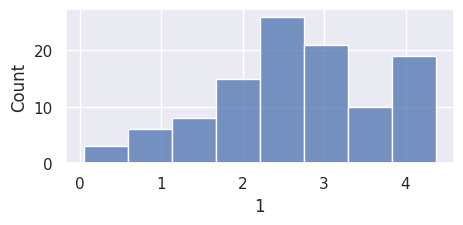

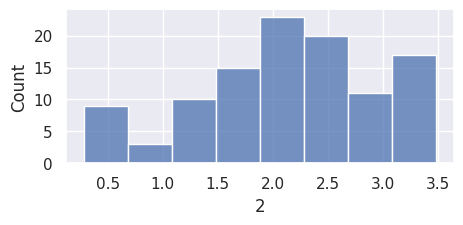

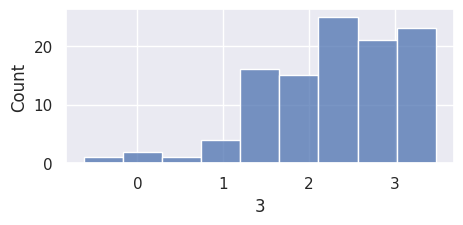

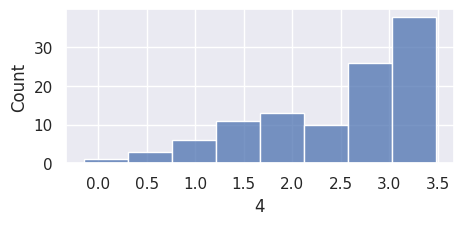

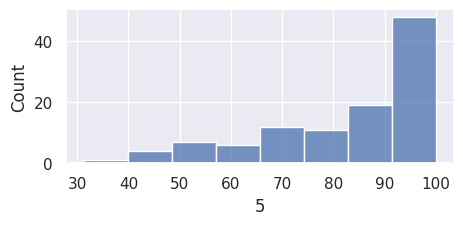

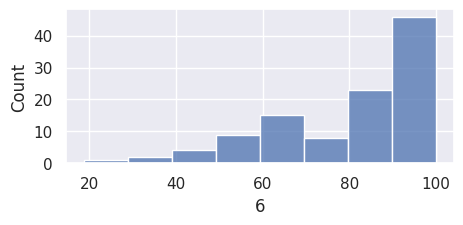

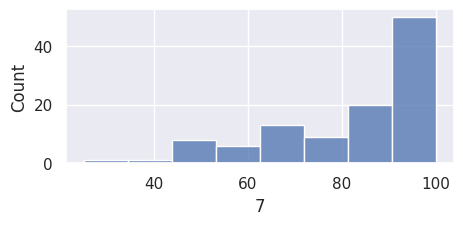

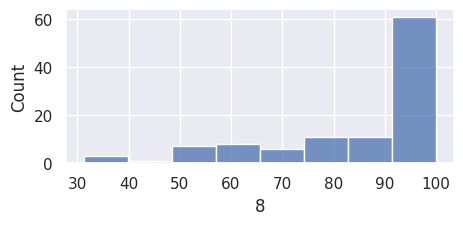

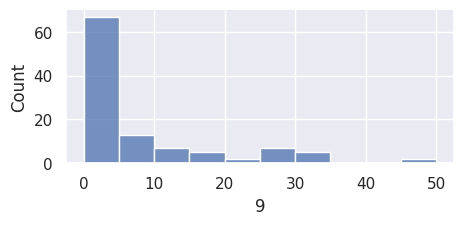

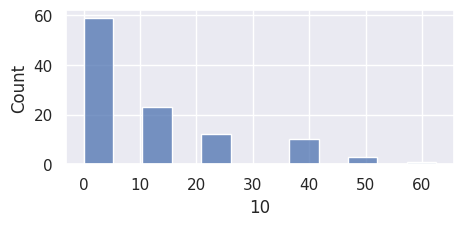

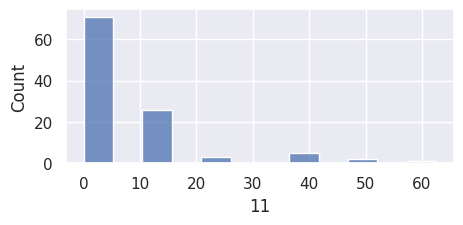

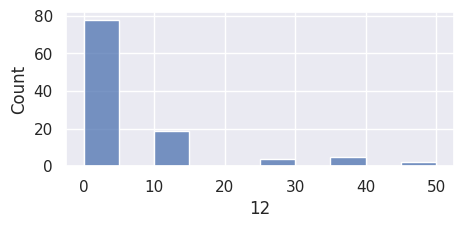

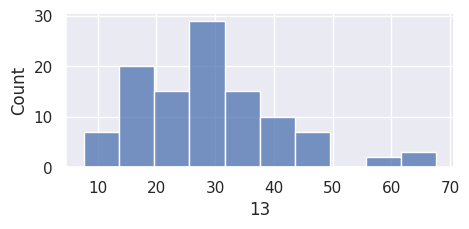

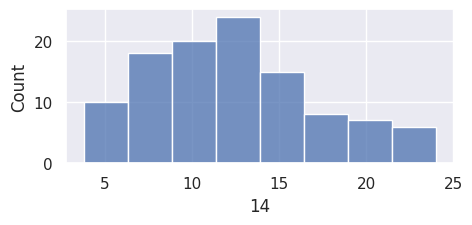

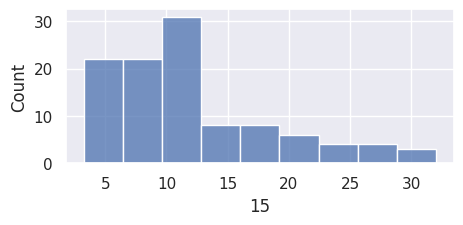

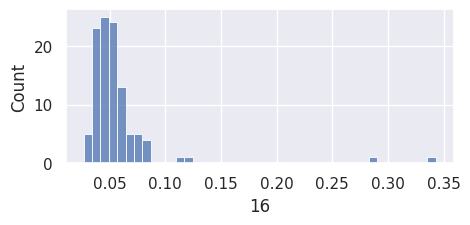

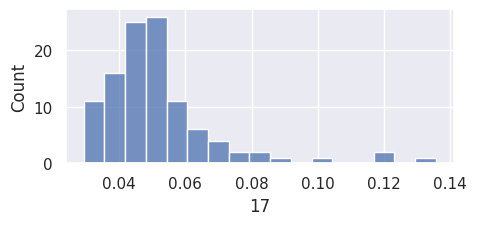

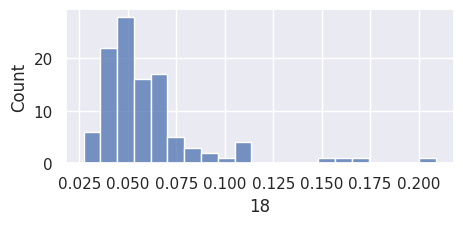

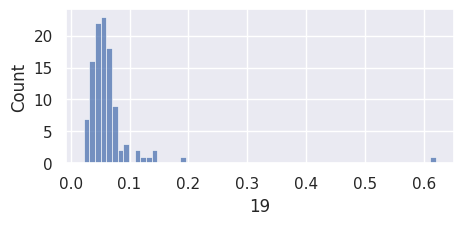

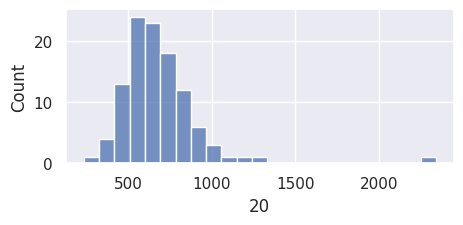

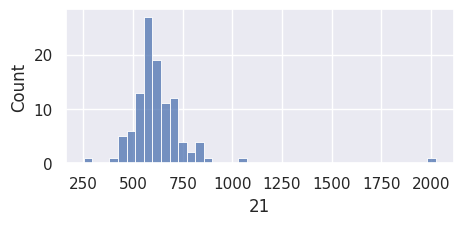

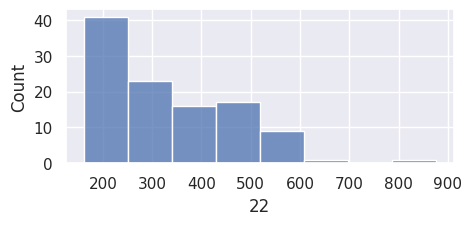

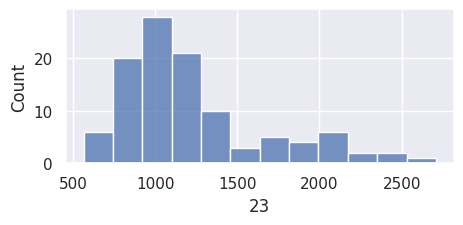

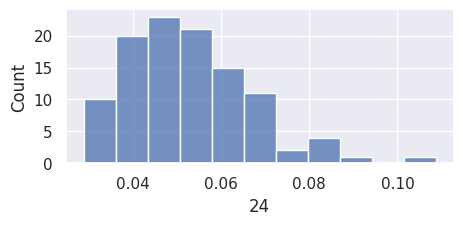

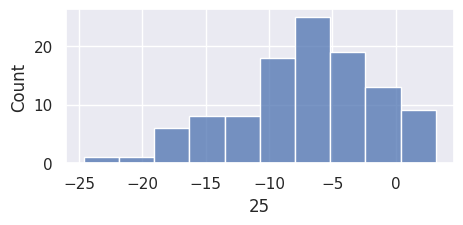

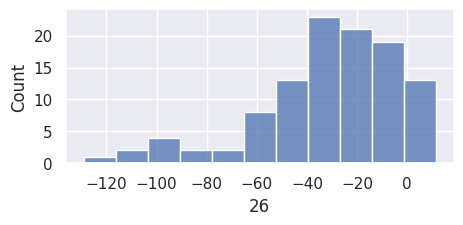

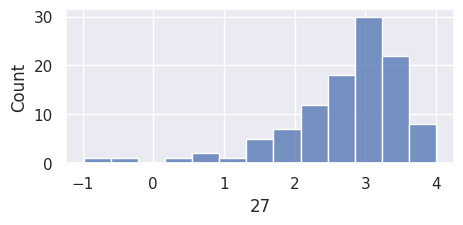

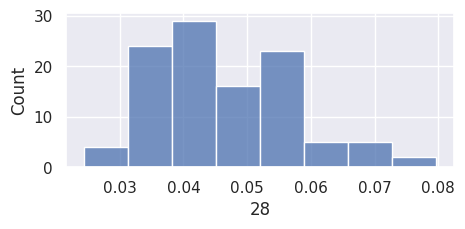

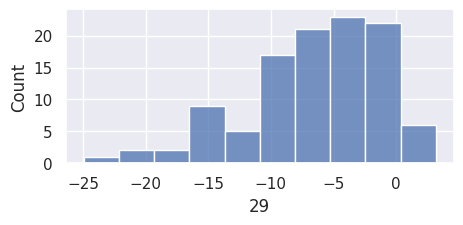

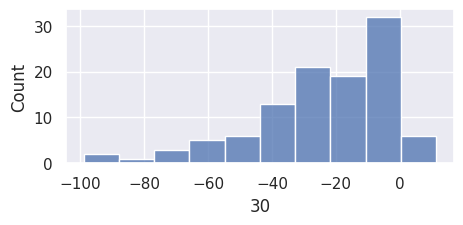

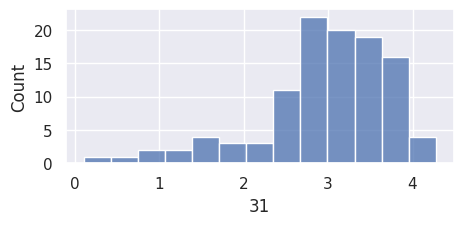

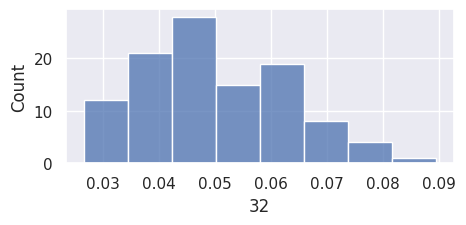

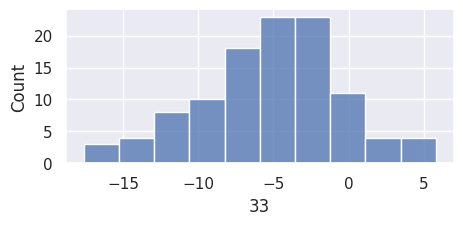

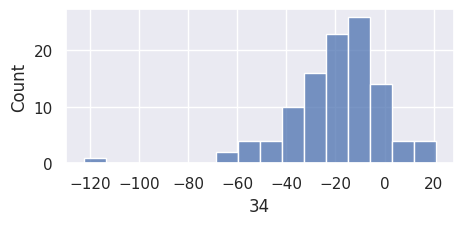

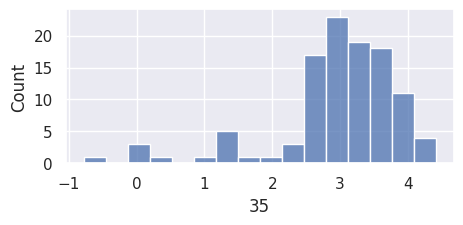

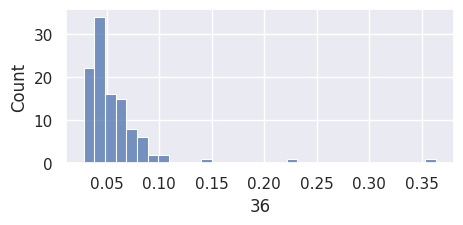

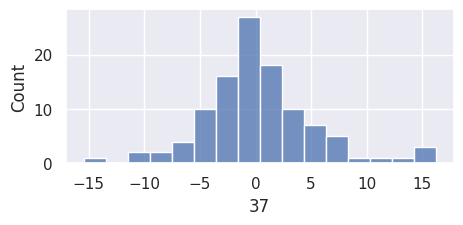

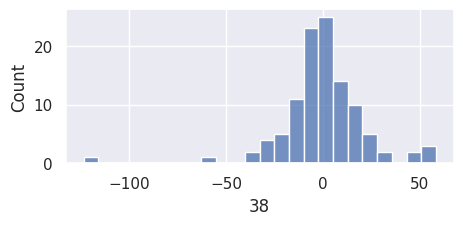

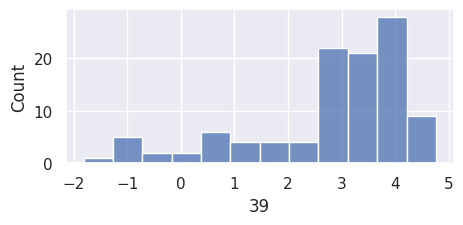

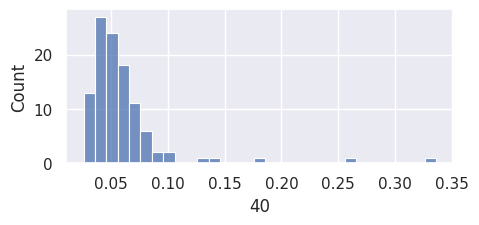

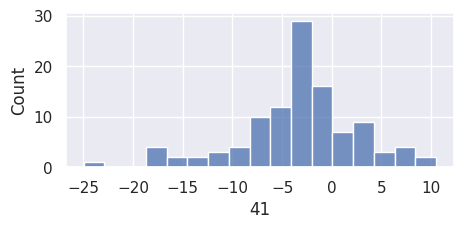

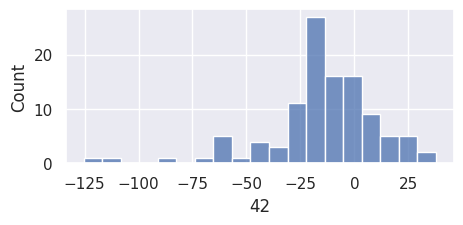

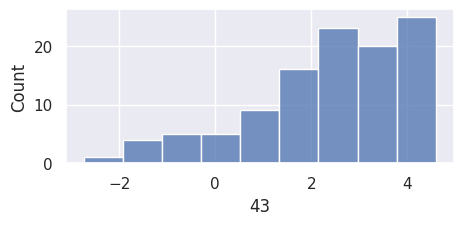

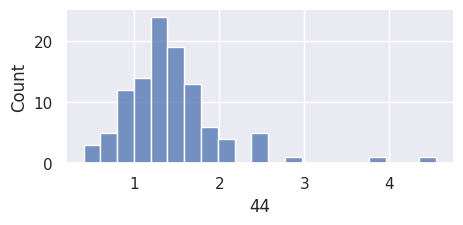

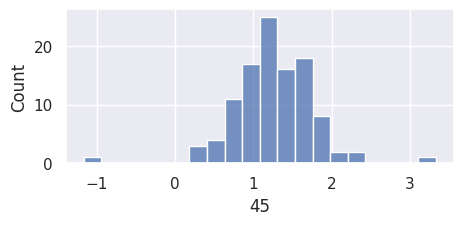

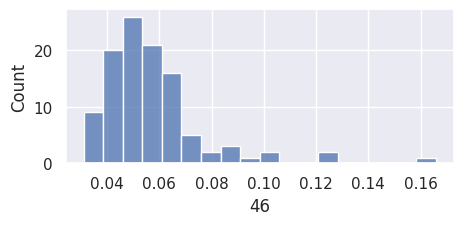

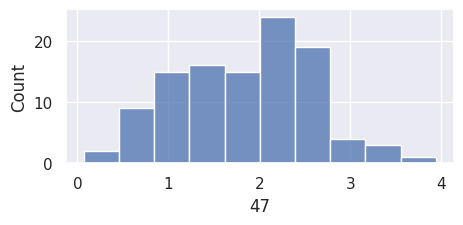

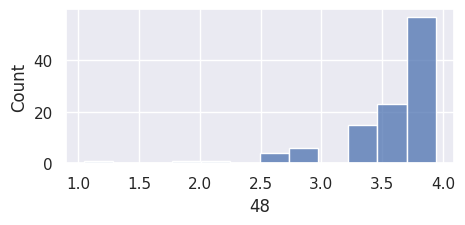

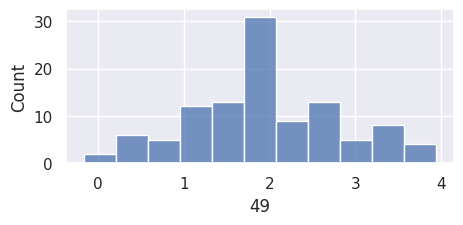

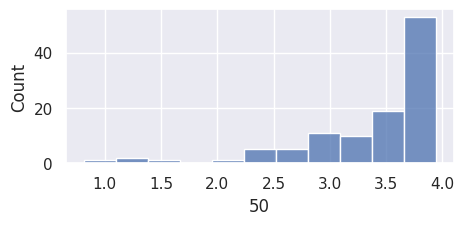

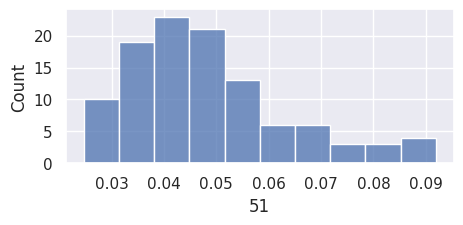

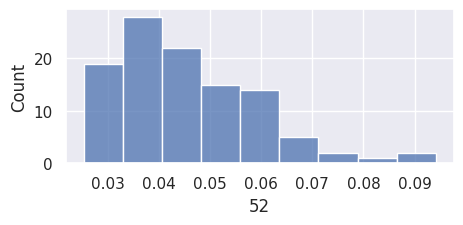

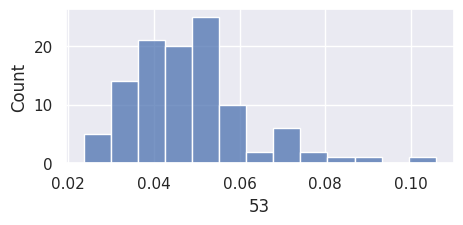

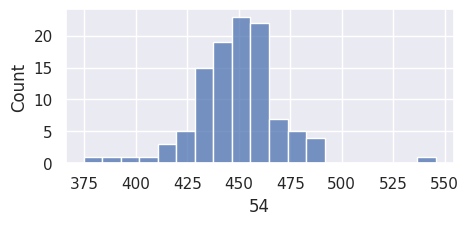

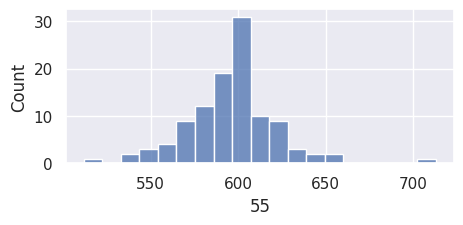

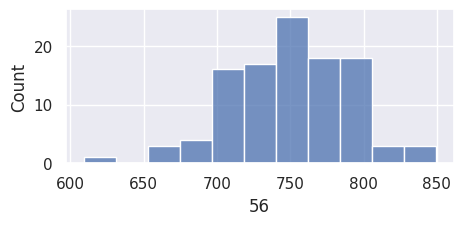

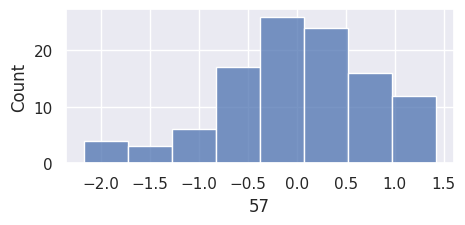

In [354]:
for col in df_comp_renamed.columns[4:]:
    plt.figure(figsize=(5,2))
    sns.histplot(data=df_comp_renamed, x=col)

### rejecting outliers

In [368]:
df_comp_renamed_outlier_rejected = copy.deepcopy(df_comp_renamed)

In [355]:
# those columns that need to be considered for outlier rejection
prep_in_need = [7, 8, 9, 11, 12, 16, 17, 18, 19, 20, 21, 22, 27, 34, 35, 36, 38, 40, 42, 44, 45, 46]

<AxesSubplot: xlabel='46', ylabel='Count'>

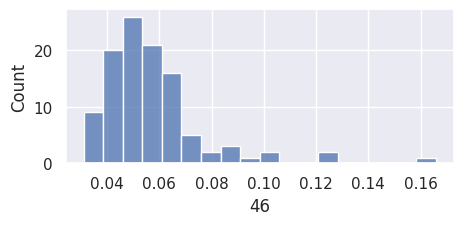

In [425]:
sns.histplot(data=df_comp_renamed_outlier_rejected, x=46)

In [427]:
chosen_to_outlier_reject = [16, 19, 20, 21, 34, 36, 38, 40]

In [418]:
df_comp_renamed_outlier_rejected[40].describe()

count    108.000000
mean       0.059951
std        0.040066
min        0.026074
25%        0.040310
50%        0.051557
75%        0.064123
max        0.335752
Name: 40, dtype: float64

In [419]:
np.sort(df_comp_renamed_outlier_rejected[40])

array([0.0260744 , 0.02739785, 0.02796328, 0.03000622, 0.03113006,
       0.03121555, 0.03198333, 0.03201648, 0.03357292, 0.03363605,
       0.03419791, 0.03522091, 0.0356799 , 0.03630808, 0.0364644 ,
       0.03672104, 0.03685732, 0.03686735, 0.03708801, 0.03758386,
       0.03780707, 0.03789996, 0.03810311, 0.03846781, 0.03862428,
       0.03905415, 0.03932577, 0.04063817, 0.0415848 , 0.04167817,
       0.04175228, 0.04192476, 0.04205312, 0.04230239, 0.04379666,
       0.04410468, 0.04443178, 0.04473672, 0.04496715, 0.04546748,
       0.04626672, 0.04709513, 0.04802728, 0.04865162, 0.04883511,
       0.0488894 , 0.04924299, 0.04994562, 0.05001524, 0.05030044,
       0.05047767, 0.05107828, 0.05115832, 0.0512557 , 0.05185823,
       0.05246502, 0.05252799, 0.05269902, 0.05371105, 0.05374448,
       0.05411208, 0.05424625, 0.05436015, 0.05582172, 0.0561557 ,
       0.05684646, 0.05688515, 0.05743043, 0.05777015, 0.05799075,
       0.05814247, 0.05890657, 0.05903987, 0.05995136, 0.05995

In [420]:
df_comp_renamed_outlier_rejected[40][df_comp_renamed_outlier_rejected[40] > 0.15] = 0.13735961

/tmp/ipykernel_1090924/926399393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comp_renamed_outlier_rejected[40][df_comp_renamed_outlier_rejected[40] > 0.15] = 0.13735961


### saving outlier rejected data

In [430]:
name_columns_mappings = {v:k for k,v in columns_name_mappings.items()}

df_comp_outlier_rejected = df_comp_renamed_outlier_rejected.rename(columns=name_columns_mappings)

df_comp_outlier_rejected.to_csv('data/baasta-data-joncannon_outlier_rejected.csv', index=False)

### reading outlier rejected data

In [39]:
df_comp_outlier_rejected = pd.read_csv('data/baasta-data-joncannon_outlier_rejected.csv')

In [40]:
columns_arr = df_comp.columns.values[4:]
columns_name_mappings = dict()
for i, name in enumerate(columns_arr):
    columns_name_mappings[name] = i + 1
    
df_comp_outlier_rejected_renamed = df_comp_outlier_rejected.rename(columns=columns_name_mappings)

In [41]:
def swap_columns(df, col1, col2):
    col_list = list(df.columns)
    x, y = col_list.index(col1), col_list.index(col2)
    col_list[y], col_list[x] = col_list[x], col_list[y]
    df = df[col_list]
    return df

In [42]:
## You don't need to do this, it has been done before and saved !

# sawpping age and ageGroup so all numerical columns are side by side

# df_comp_outlier_rejected_renamed = swap_columns(df_comp_outlier_rejected_renamed, 'age', 'ageGroup')
# df_comp_outlier_rejected_renamed = swap_columns(df_comp_outlier_rejected_renamed, 'gender', 'ageGroup')

### normalizing data

In [43]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer().fit(df_comp_outlier_rejected_renamed.iloc[:,2:].values)  # fit does nothing.

In [44]:
df_comp_outlier_rejected_renamed_norm = copy.deepcopy(df_comp_outlier_rejected_renamed)
df_comp_outlier_rejected_renamed_norm.iloc[:,2:] = normalizer.transform(df_comp_outlier_rejected_renamed.iloc[:,2:].values)

#### saving normalized data

In [109]:
name_columns_mappings = {v:k for k,v in columns_name_mappings.items()}
df = df_comp_outlier_rejected_renamed_norm.rename(columns=name_columns_mappings)
df.to_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv', index=False)

### standardizing data

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(df_comp_outlier_rejected_renamed.iloc[:,2:].values)

In [111]:
df_comp_outlier_rejected_renamed_scaled = copy.deepcopy(df_comp_outlier_rejected_renamed)
df_comp_outlier_rejected_renamed_scaled.iloc[:,2:] = scaler.transform(df_comp_outlier_rejected_renamed.iloc[:,2:].values)

#### saving scaled data

In [112]:
name_columns_mappings = {v:k for k,v in columns_name_mappings.items()}
df = df_comp_outlier_rejected_renamed_scaled.rename(columns=name_columns_mappings)
df.to_csv('data/baasta-data-joncannon_outlier_rejected_scaled.csv', index=False)

# Analysis

## Correlation

### pearson

<AxesSubplot: >

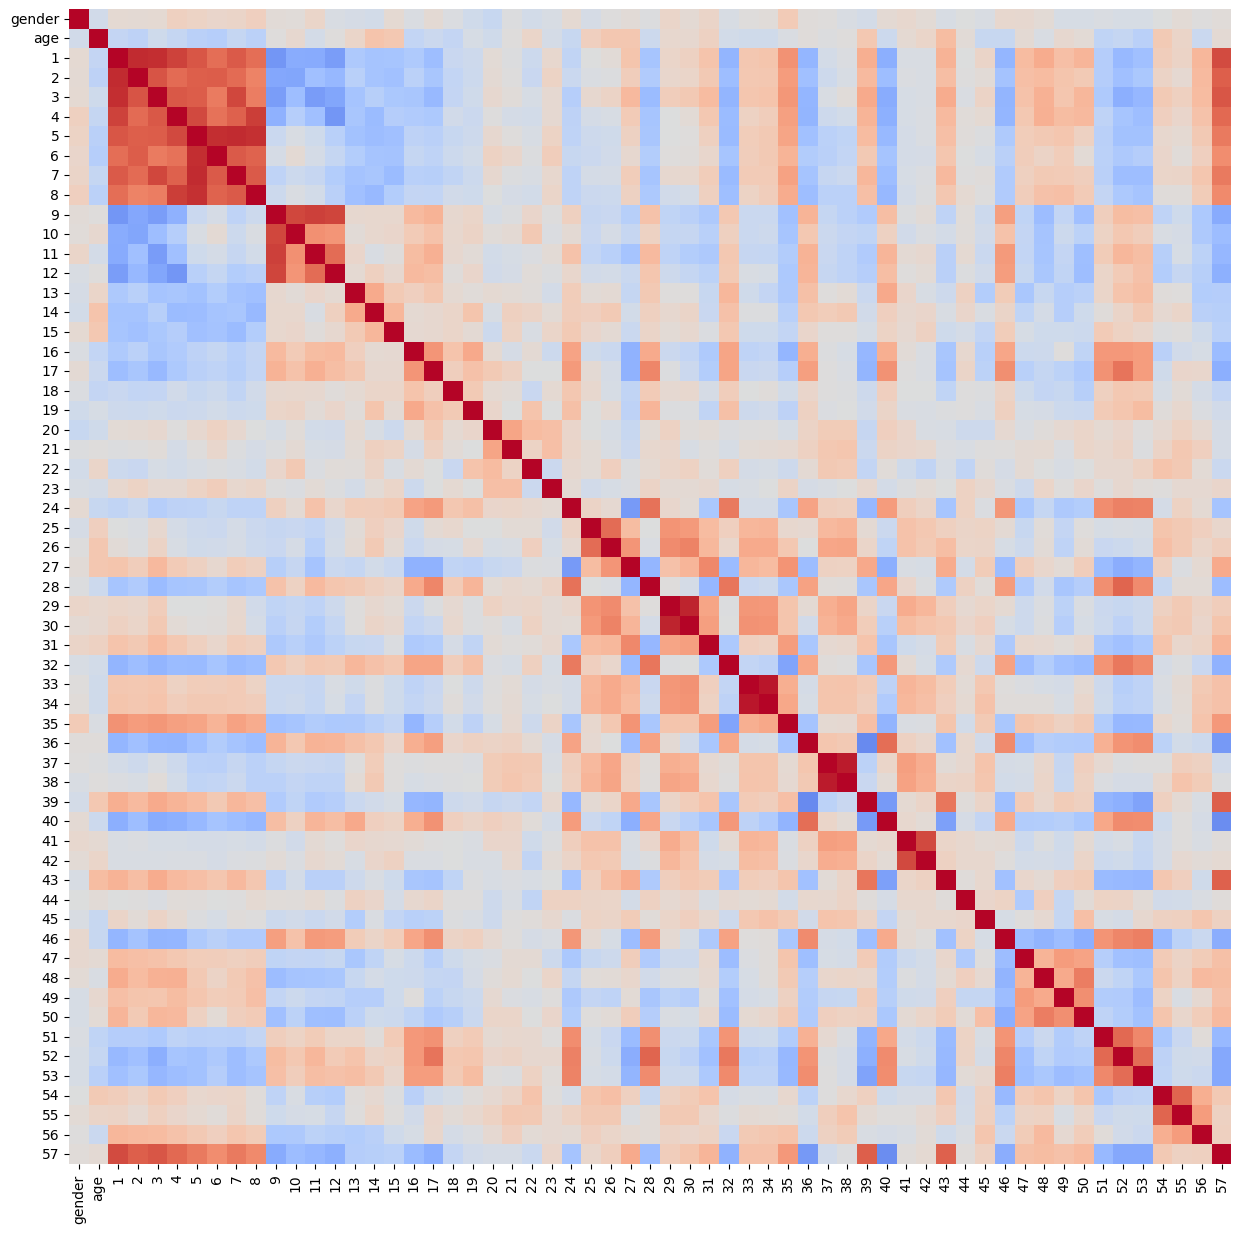

In [17]:
pearson_corr = df_comp_outlier_rejected_renamed_scaled.iloc[:,2:].corr(method='pearson')
plt.figure(figsize=(15,15))
sns.heatmap(data=pearson_corr, vmin=-1, vmax=1, cmap='coolwarm', cbar=False)

### spearman

<AxesSubplot: >

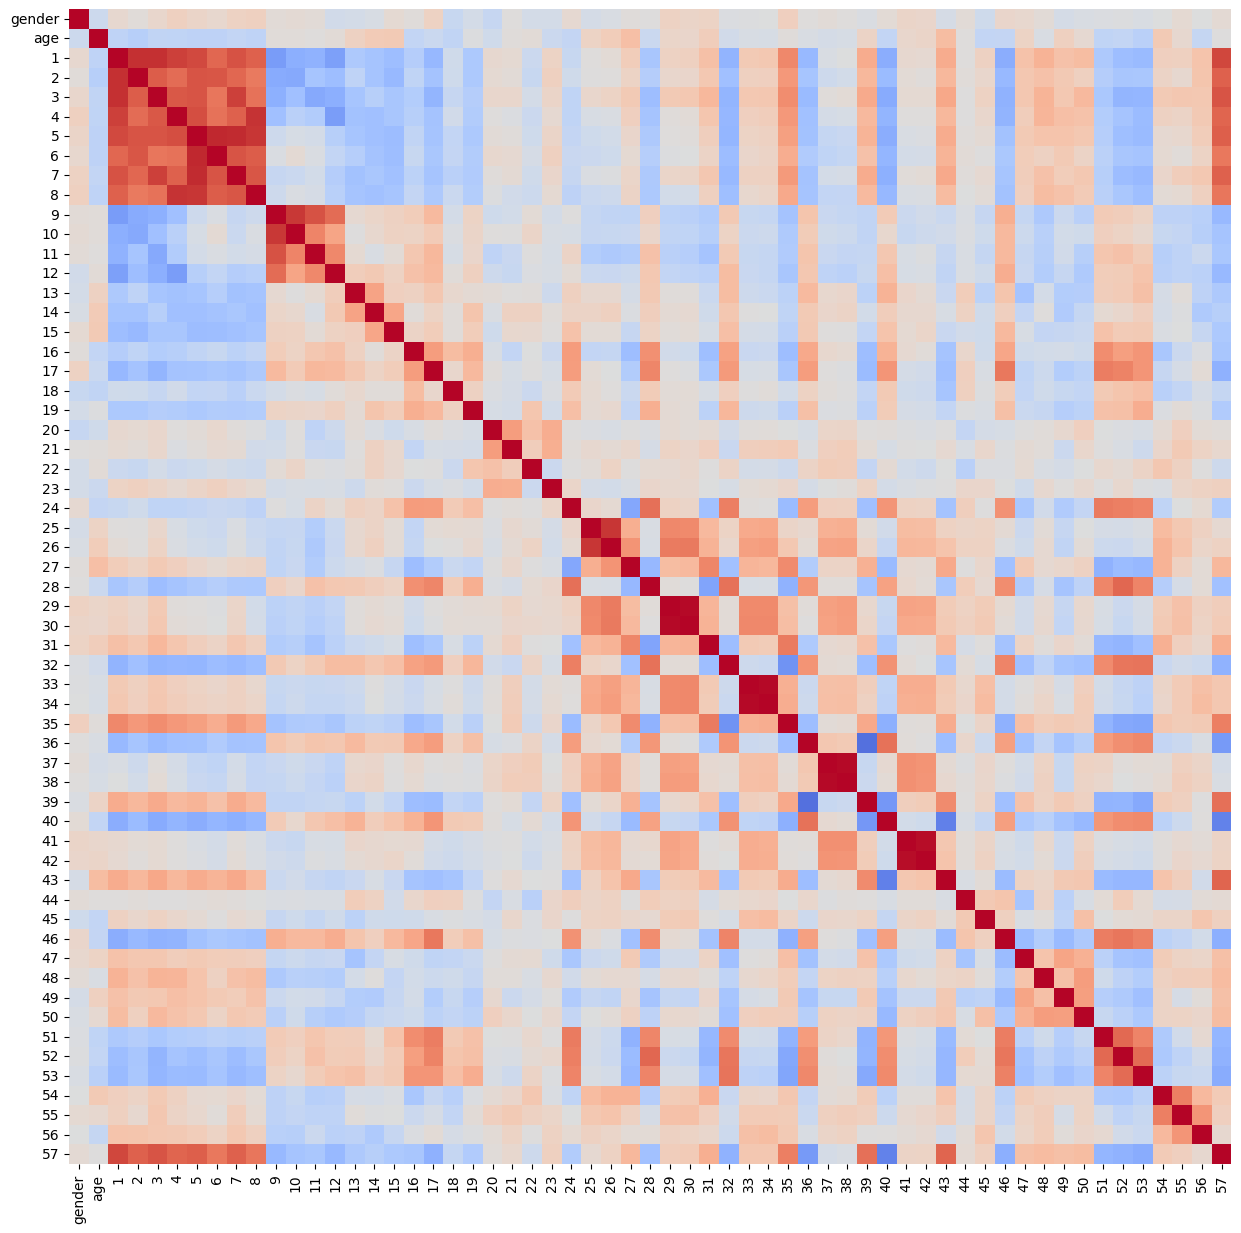

In [18]:
spearman_corr = df_comp_outlier_rejected_renamed_scaled.iloc[:,2:].corr(method='spearman')
plt.figure(figsize=(15,15))
sns.heatmap(data=spearman_corr, vmin=-1, vmax=1, cmap='coolwarm', cbar=False)

### changing the name for simplicity

## sorting the correlation matrices

In [49]:
def optimal_reorder(df, hierarchy_method='ward', correlation_method='spearman'):
    columns_arr = df.columns.values
    columns_name_mappings = dict()
    for i, name in enumerate(columns_arr):
        columns_name_mappings[i] = name
            
    linkage_mat = shc.linkage(df.T, method =hierarchy_method)
    optimal_arr = shc.leaves_list(shc.optimal_leaf_ordering(linkage_mat, df.T))
    optimal_names = [columns_name_mappings[i] for i in optimal_arr]
    df_reordered = df[optimal_names]
    
    corr = df_reordered.corr(method=correlation_method)

    
    return df_reordered, optimal_names, corr

## normalized data

<AxesSubplot: >

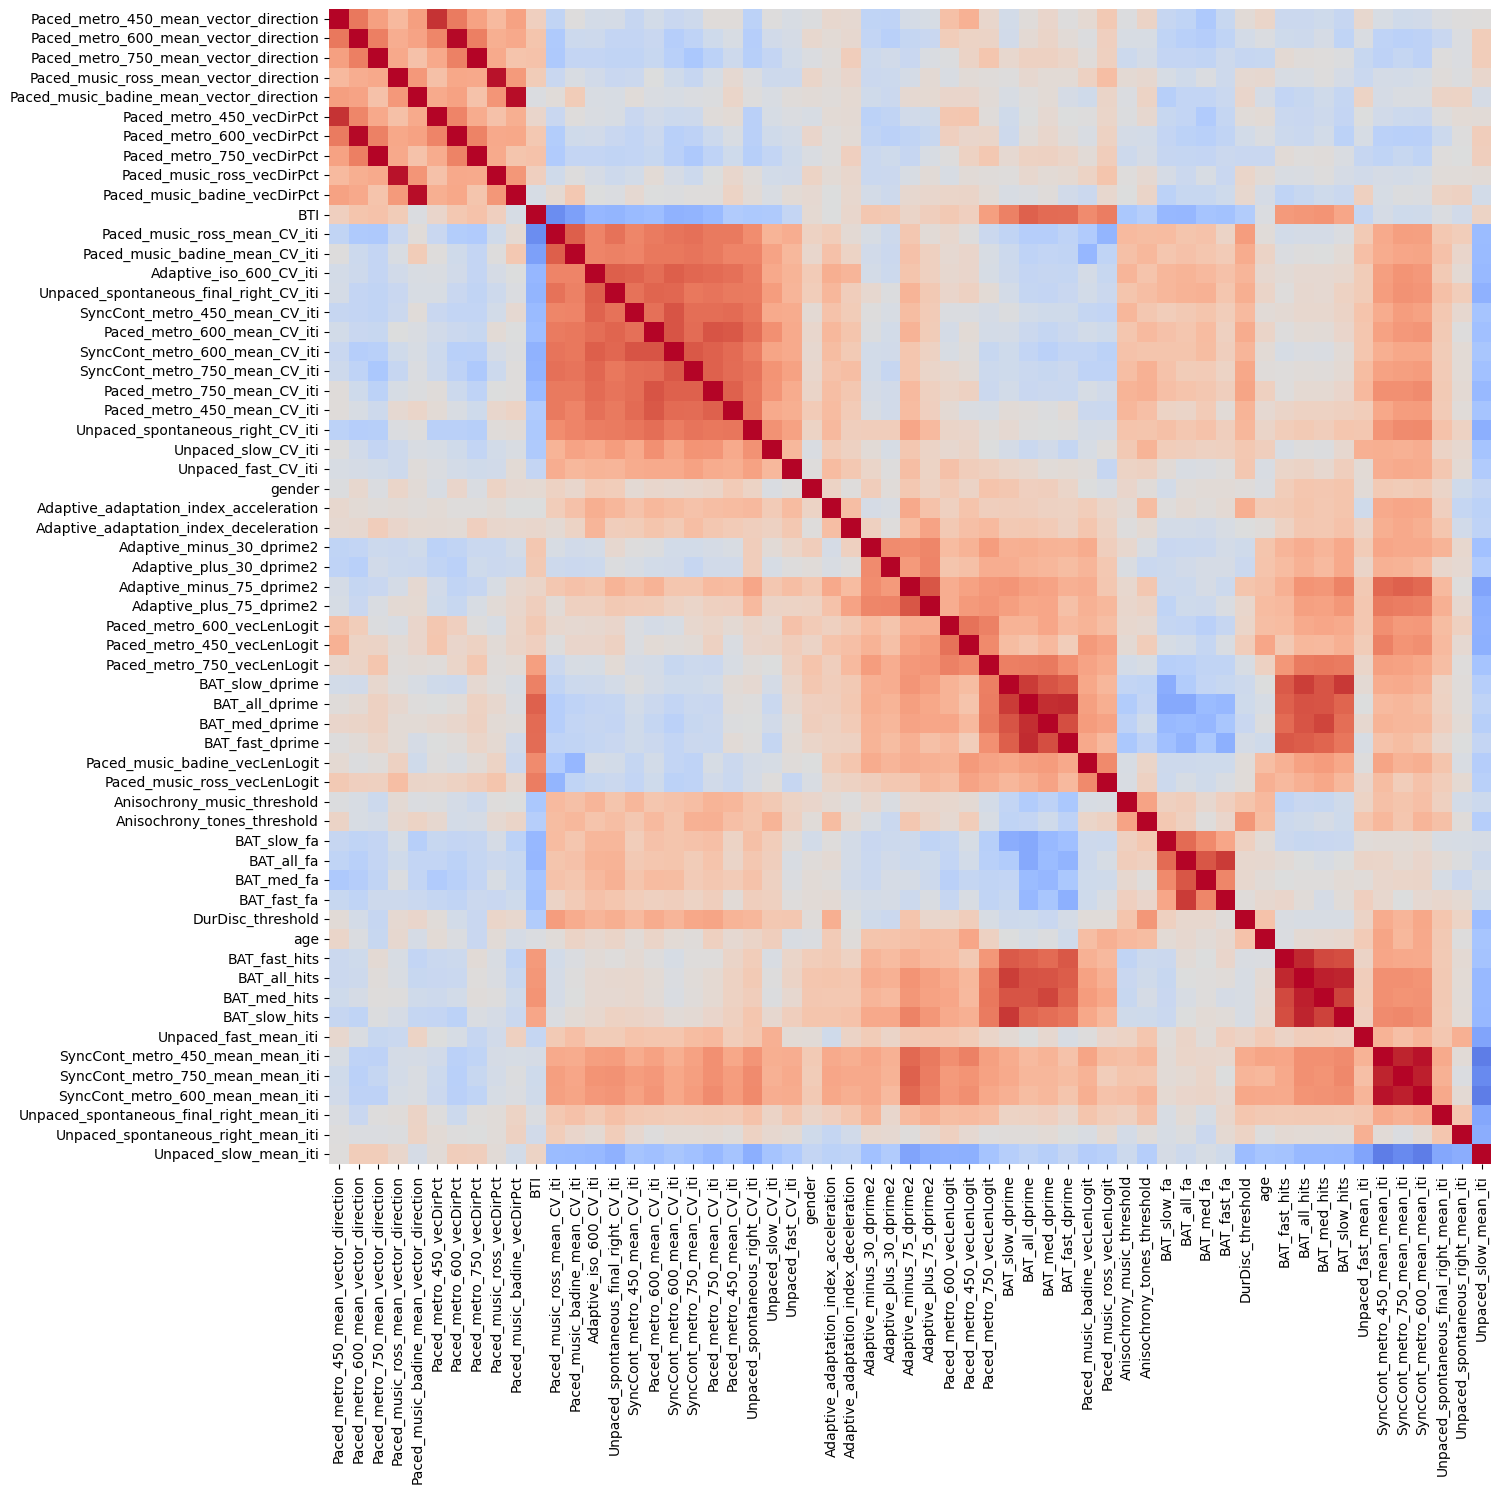

In [50]:
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
corr = optimal_reorder(df_normalized.iloc[:,2:])[-1]
plt.figure(figsize=(15,15))
sns.heatmap(data=corr, vmin=-1, vmax=1, cmap='coolwarm', cbar=False)

### scaled data

<AxesSubplot: >

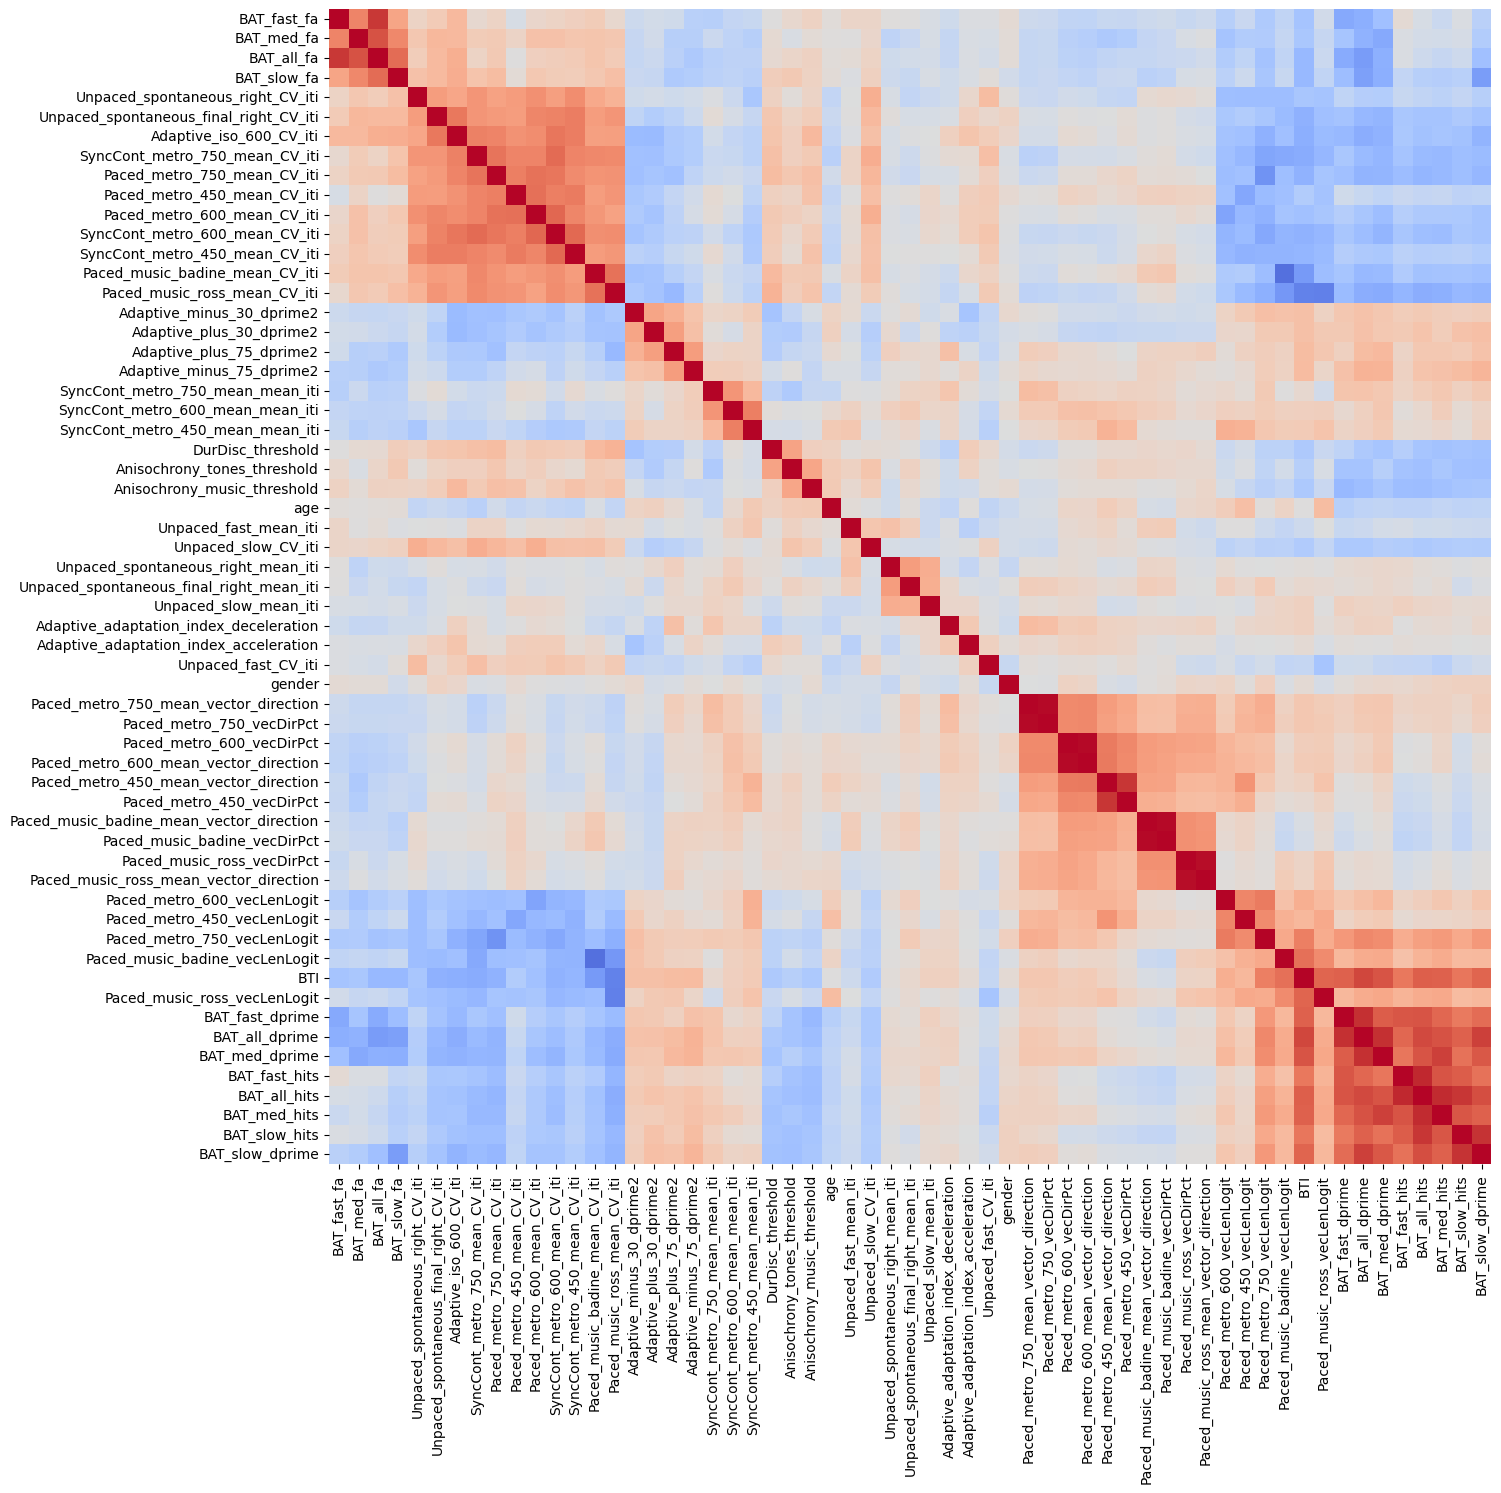

In [51]:
df_scaled = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_scaled.csv')
corr = optimal_reorder(df_scaled.iloc[:,2:])[-1]
plt.figure(figsize=(15,15))
sns.heatmap(data=corr, vmin=-1, vmax=1, cmap='coolwarm', cbar=False)

In [52]:
df_original = pd.read_csv('data/baasta-data-joncannon_outlier_rejected.csv')

## PCA

### normalized

<AxesSubplot: >

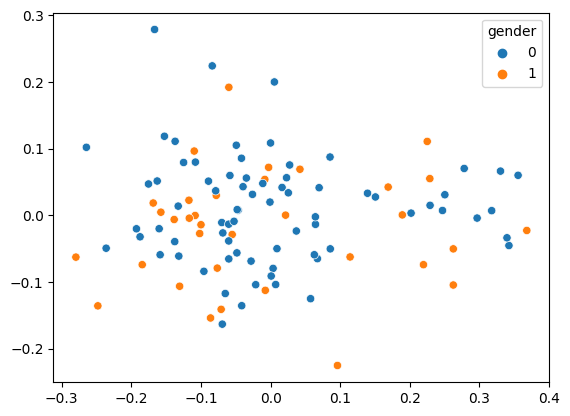

In [55]:
pca_norm = PCA(n_components=3)
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
pca_norm.fit(df_normalized.iloc[:,2:])

norm_pca = pca_norm.transform(X=df_normalized.iloc[:,2:])

sns.scatterplot(x=norm_pca[:,0], y=norm_pca[:,1], hue=df_original['gender'])

In [58]:
def f(x, y):
    return np.sin(np.sqrt(x ** 2 + y ** 2))

x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

In [62]:
Z.shape

(30, 30)

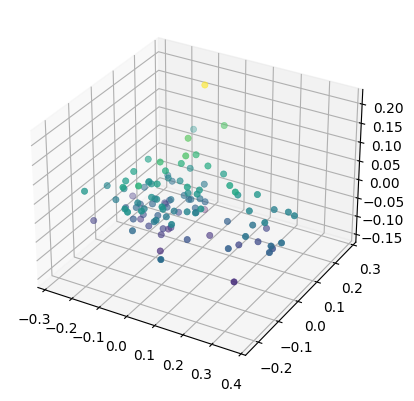

In [63]:
fig = plt.figure()
ax = plt.axes(projection='3d')
X = norm_pca[:,0]
Y = norm_pca[:,1]
Z = norm_pca[:,2]
ax.scatter(X, Y, Z, c=Z, cmap='viridis', linewidth=0.5);

In [64]:
pca_norm.explained_variance_ratio_.sum()

0.8878775779369931

### Scaled

<AxesSubplot: >

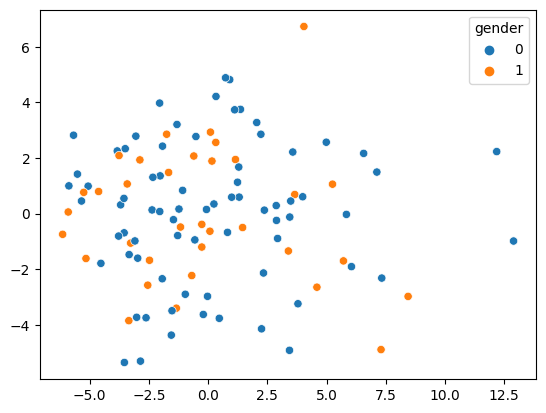

In [194]:
pca_scaled = PCA(n_components=2)
df_scaled = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_scaled.csv')
pca_scaled.fit(df_scaled.iloc[:,2:])

scaled_pca = pca_scaled.transform(X=df_scaled.iloc[:,2:])

sns.scatterplot(x=scaled_pca[:,0], y=scaled_pca[:,1], hue=df_original['gender'])

In [195]:
pca_scaled.explained_variance_ratio_.sum()

0.344575894785488

## tSNE

### normalized

In [37]:
import numpy as np
from sklearn.manifold import TSNE
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
X_embedded = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=3).fit_transform(X)
X_embedded.shape

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U4'), dtype('float32')) -> None

In [16]:
x_d = df_normalized.iloc[:,2:].to_numpy()

In [32]:
x_s = np.random.rand(108, 59)

In [30]:
df_normalized.iloc[:,2:].shape

(108, 59)

In [23]:
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 61 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   subject_session                           108 non-null    object 
 1   ageGroup                                  108 non-null    object 
 2   gender                                    108 non-null    float64
 3   age                                       108 non-null    float64
 4   BAT_all_dprime                            108 non-null    float64
 5   BAT_fast_dprime                           108 non-null    float64
 6   BAT_med_dprime                            108 non-null    float64
 7   BAT_slow_dprime                           108 non-null    float64
 8   BAT_all_hits                              108 non-null    float64
 9   BAT_fast_hits                             108 non-null    float64
 10  BAT_med_hits                          

In [33]:
tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=15)
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
tnse_normalized_data = tsne_norm.fit_transform(x_s)

sns.scatterplot(x=tnse_normalized_data[:,0], y=tnse_normalized_data[:,1], hue=df_original['gender'])

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U4'), dtype('float32')) -> None

### scaled

<AxesSubplot: >

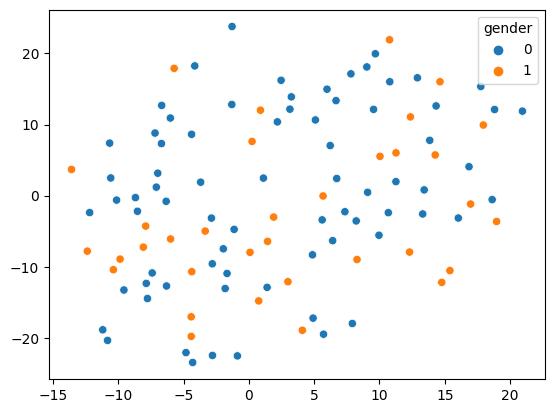

In [190]:
tsne_scaled = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=11)
df_scaled = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_scaled.csv')
tnse_scaled_data = tsne_scaled.fit_transform(df_scaled.iloc[:,2:])

sns.scatterplot(x=tnse_scaled_data[:,0], y=tnse_scaled_data[:,1], hue=df_original['gender'])

# Kmeans

## 2 clusters

<AxesSubplot: >

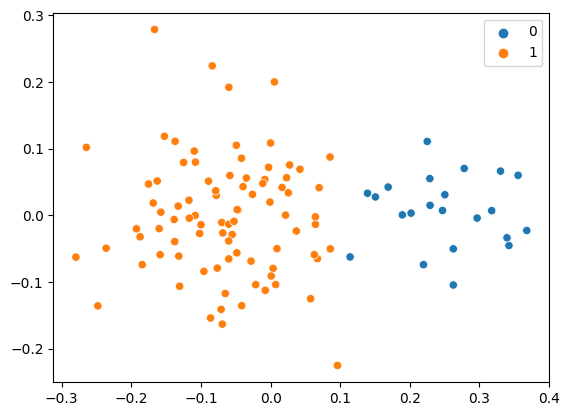

In [74]:
from sklearn.cluster import KMeans

kmeans_norm = KMeans(n_clusters=2, random_state=0, n_init="auto")
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
kmeans_norm.fit(df_normalized.iloc[:,2:])

pca_norm = PCA(n_components=2)
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
pca_norm.fit(df_normalized.iloc[:,2:])

norm_pca = pca_norm.transform(X=df_normalized.iloc[:,2:])

sns.scatterplot(x=norm_pca[:,0], y=norm_pca[:,1], hue=kmeans_norm.labels_)

In [75]:
# I can do the elbow method

## tSTNE

<AxesSubplot: >

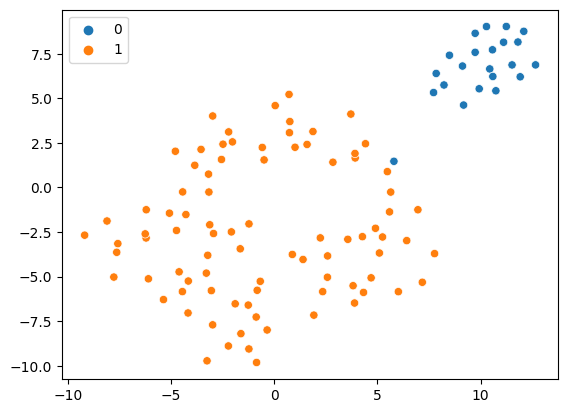

In [80]:
from sklearn.cluster import KMeans

kmeans_norm = KMeans(n_clusters=2, random_state=0, n_init="auto")
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
kmeans_norm.fit(df_normalized.iloc[:,2:])

tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=20)
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
tnse_normalized_data = tsne_norm.fit_transform(df_normalized.iloc[:,2:])

sns.scatterplot(x=tnse_normalized_data[:,0], y=tnse_normalized_data[:,1], hue=kmeans_norm.labels_)

## 3 clusters

<AxesSubplot: >

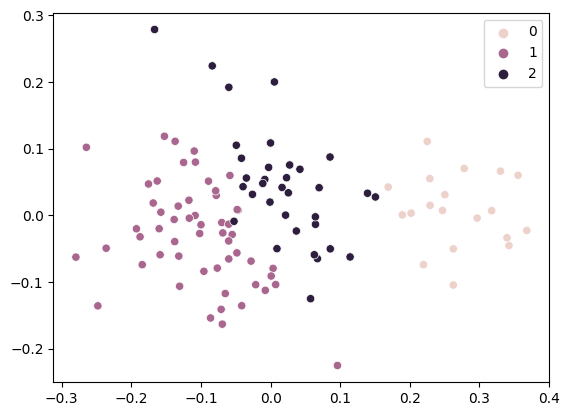

In [81]:
from sklearn.cluster import KMeans

kmeans_norm = KMeans(n_clusters=3, random_state=0, n_init="auto")
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
kmeans_norm.fit(df_normalized.iloc[:,2:])

pca_norm = PCA(n_components=2)
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
pca_norm.fit(df_normalized.iloc[:,2:])

norm_pca = pca_norm.transform(X=df_normalized.iloc[:,2:])

sns.scatterplot(x=norm_pca[:,0], y=norm_pca[:,1], hue=kmeans_norm.labels_)

In [82]:
# I can do the elbow method

## tSTNE

<AxesSubplot: >

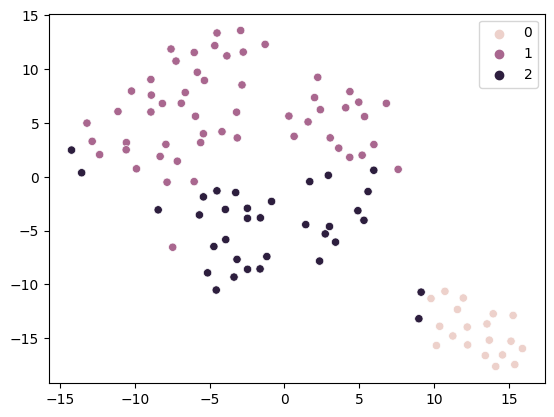

In [87]:
from sklearn.cluster import KMeans

kmeans_norm = KMeans(n_clusters=3, random_state=0, n_init="auto")
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
kmeans_norm.fit(df_normalized.iloc[:,2:])

tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=15)
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')
tnse_normalized_data = tsne_norm.fit_transform(df_normalized.iloc[:,2:])

sns.scatterplot(x=tnse_normalized_data[:,0], y=tnse_normalized_data[:,1], hue=kmeans_norm.labels_)